In [2]:
import numpy as np
import pandas as pd
from finance_byu.summarize import summary
from finance_byu.regtables import Regtable
import statsmodels.formula.api as smf
from scipy import stats

In [3]:
# load FF3 and FF5 factor data
# FF3 contains: Mkt-RF, SMB, HML, RF
# FF5 adds: RMW and CMA 

ff3 = pd.read_csv('FF3_factor_data.csv')
ff3.columns = ff3.columns.str.lower()
ff3 = ff3.rename(columns={'mkt-rf': 'exmkt'})
ff3['date'] = pd.to_datetime(ff3['date'], format='%Y%m').dt.to_period('M')
ff3 = ff3[(ff3['date'] >= '1963-07') & (ff3['date'] <= '1995-07')]

ff5 = pd.read_csv('FF5_factor_data.csv')
ff5.columns = ff5.columns.str.lower()
ff5 = ff5.rename(columns={'mkt-rf': 'exmkt'})
ff5['date'] = pd.to_datetime(ff5['date'], format='%Y%m').dt.to_period('M')
ff5 = ff5[(ff5['date'] >= '1963-07') & (ff5['date'] <= '1995-07')]

In [4]:
def load_and_process(filepath, n_industries, L=6):
    # load
    df = pd.read_csv(filepath, na_values=[-99.99])
    
    # clean dates and column names
    df.columns = df.columns.str.lower()
    df['date'] = pd.to_datetime(df['date'], format='%Y%m').dt.to_period('M')
    
    # melt columns
    df = df.melt(id_vars='date', var_name='industry', value_name='industry_return')
    
    # calculate momentum on full history first so rolling window has prior data
    # L controls the formation period length (paper tests L = 1, 6, 12 months)
    # use simple cumulative returns as used in paper
    df['mom'] = (df.groupby('industry')['industry_return']
                   .transform(lambda x: (1 + x/100).shift(1)
                   .rolling(L).apply(lambda r: r.prod() - 1)))
    
    # filter to paper's sample period after momentum is computed
    df = df[(df['date'] >= '1963-07') & (df['date'] <= '1995-07')]
    
    # rank industries each month
    df['rank'] = df.groupby('date')['mom'].rank(ascending=False)
    
    # label winners and losers
    df['portfolio'] = 'middle'
    df.loc[df['rank'] <= 3, 'portfolio'] = 'winner'
    df.loc[df['rank'] > n_industries - 3, 'portfolio'] = 'loser'
    
    return df

# run for all three using default L=6 to keep existing results unchanged
df17 = load_and_process('17_Industry_Portfolios.csv', 17)
df30 = load_and_process('30_Industry_Portfolios.csv', 30)
df48 = load_and_process('48_Industry_Portfolios.csv', 48)

In [5]:
df17

,date,industry,industry_return,mom,rank,portfolio
444,1963-07,food,-0.15,0.097020,11.0,middle
445,1963-08,food,4.60,0.027748,14.0,middle
446,1963-09,food,-1.26,0.109302,12.0,middle
447,1963-10,food,2.09,0.073322,11.0,middle
448,1963-11,food,-0.47,0.085442,6.0,middle
...,...,...,...,...,...,...
19944,1995-03,other,2.31,0.041579,5.0,middle
19945,1995-04,other,1.86,0.071425,9.0,middle
19946,1995-05,other,1.06,0.079372,10.0,middle
19947,1995-06,other,5.28,0.136620,11.0,middle


In [6]:
df30

,date,industry,industry_return,mom,rank,portfolio
444,1963-07,food,0.04,0.099211,17.0,middle
445,1963-08,food,4.82,0.031083,17.0,middle
446,1963-09,food,-1.43,0.111115,17.0,middle
447,1963-10,food,2.41,0.076707,15.0,middle
448,1963-11,food,-0.46,0.090442,8.0,middle
...,...,...,...,...,...,...
35479,1995-03,other,3.39,-0.029986,22.0,middle
35480,1995-04,other,1.34,0.039057,20.0,middle
35481,1995-05,other,4.65,0.041420,21.0,middle
35482,1995-06,other,2.53,0.161140,17.0,middle


In [7]:
df48

,date,industry,industry_return,mom,rank,portfolio
444,1963-07,agric,3.04,0.245943,3.0,winner
445,1963-08,agric,-0.32,0.159310,1.0,winner
446,1963-09,agric,-1.94,0.227403,5.0,middle
447,1963-10,agric,-0.13,0.227528,1.0,winner
448,1963-11,agric,-3.06,0.087784,13.0,middle
...,...,...,...,...,...,...
56989,1995-03,other,3.21,-0.093782,45.0,middle
56990,1995-04,other,0.15,-0.042478,44.0,middle
56991,1995-05,other,5.08,-0.038735,43.0,middle
56992,1995-06,other,4.09,0.105502,36.0,middle


In [8]:
def compute_wml(df, H=6):
    monthly = df.groupby(['date', 'portfolio'])['industry_return'].mean().unstack()
    monthly['wml'] = monthly['winner'] - monthly['loser']
    monthly['wml'] = monthly['wml'].rolling(H, min_periods=H).mean()
    return monthly

wml17 = compute_wml(df17)
wml30 = compute_wml(df30)
wml48 = compute_wml(df48)

In [9]:
# compute mean monthly WML returns and t-statistics for each industry classification
# paper target: mean = 0.43% per month, t-stat = 4.24 (using 20 industries, 1963-1995)

for name, wml in [('17', wml17), ('30', wml30), ('48', wml48)]:
    mean = wml['wml'].mean()
    tstat = stats.ttest_1samp(wml['wml'].dropna(), 0).statistic
    print(f'{name} industries: mean = {mean:.4f}, t-stat = {tstat:.2f}')

17 industries: mean = 0.3896, t-stat = 3.95
30 industries: mean = 0.7340, t-stat = 7.10
48 industries: mean = 0.8634, t-stat = 6.69


In [10]:
# summary statistics for winner, loser, and WML portfolios
# replicates paper's Table II Panel B reporting mean and t-stat

for name, wml in [('17', wml17), ('30', wml30), ('48', wml48)]:
    w = wml['winner'].dropna()
    l = wml['loser'].dropna()
    m = wml['wml'].dropna()
    
    print(f'\n--- {name} Industries ---')
    print(f'{"":10} {"Mean":>8} {"Std":>8} {"T-stat":>8}')
    print(f'{"Winner":10} {w.mean():>8.3f} {w.std():>8.3f} {w.mean()/(w.std()/np.sqrt(len(w))):>8.2f}')
    print(f'{"Loser":10} {l.mean():>8.3f} {l.std():>8.3f} {l.mean()/(l.std()/np.sqrt(len(l))):>8.2f}')
    print(f'{"WML":10} {m.mean():>8.3f} {m.std():>8.3f} {m.mean()/(m.std()/np.sqrt(len(m))):>8.2f}')


--- 17 Industries ---
               Mean      Std   T-stat
Winner        1.213    4.948     4.81
Loser         0.822    5.198     3.10
WML           0.390    1.923     3.95

--- 30 Industries ---
               Mean      Std   T-stat
Winner        1.494    5.339     5.49
Loser         0.742    5.789     2.51
WML           0.734    2.016     7.10

--- 48 Industries ---
               Mean      Std   T-stat
Winner        1.496    5.903     4.97
Loser         0.627    6.432     1.90
WML           0.863    2.496     6.69


In [ ]:
## Cell A

# load individual stock data from CRSP
# this enables the paper's core test: does momentum survive after removing industry effects?

crsp = pd.read_csv('crsp_monthly.csv')
crsp.columns = crsp.columns.str.lower()

# parse dates to period format to match our industry data
crsp['date'] = pd.to_datetime(crsp['caldt'])
crsp['date'] = crsp['date'] + pd.offsets.MonthEnd(0)
crsp['date'] = crsp['date'].dt.to_period('M')

# standard CRSP filters used in the paper
# shrcd 10/11 = ordinary common shares only (removes REITs, ADRs, etc.)
crsp = crsp[crsp['shrcd'].isin([10, 11])]

# keep only valid returns and remove extreme outliers
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')
crsp = crsp[crsp['ret'].notna()]
crsp = crsp[crsp['ret'] > -1] # this is superfluous if we do the fourth one, isn't it.
crsp = crsp[crsp['ret'] <= 1.0]
crsp = crsp[crsp['ret'] >= -0.95]

# take absolute value of price FIRST before filtering
# CRSP uses negative prices for bid-ask midpoints so -5.0 means $5.00
crsp['prc'] = crsp['prc'].abs()
crsp = crsp[crsp['prc'] >= 1.0]   # now safe to filter penny stocks

# market equity for value weighting
crsp['me'] = crsp['prc'] * crsp['shr']
crsp = crsp[crsp['me'] > 0]

# keep only what we need
crsp = crsp[['permno', 'date', 'ret', 'me', 'siccd']].copy()

# FROM JOSEPH: This needs to be the same date range as the analysis above if we're going to use it to compare doesn' it?
# as in this needs to start from 1963
crsp = crsp[crsp['date'] <= '1995-07']

print(f'Stocks loaded: {crsp["permno"].nunique():,} unique stocks')
print(f'Observations: {len(crsp):,} stock-month rows')
print(f'Date range: {crsp["date"].min()} to {crsp["date"].max()}')

Stocks loaded: 17,011 unique stocks
Observations: 2,005,175 stock-month rows
Date range: 1926-01 to 1995-07


In [12]:
## Cell B

# assign each stock to one of 17 industries using its 4-digit SIC code
# we use the French 17-industry classification to match our industry portfolio analysis

def assign_industry(sic):
    if pd.isna(sic): return 'Other'
    sic = int(sic)
    if 2000 <= sic <= 2199: return 'Food'
    if 2200 <= sic <= 2399: return 'Clths'
    if 2500 <= sic <= 2599: return 'Durbl'
    if 2800 <= sic <= 2899: return 'Chems'
    if 2900 <= sic <= 2999: return 'Oil'
    if 1000 <= sic <= 1499: return 'Mines'
    if 1500 <= sic <= 1799: return 'Cnstr'
    if 3000 <= sic <= 3299: return 'Cnstr'
    if 3300 <= sic <= 3399: return 'Steel'
    if 3400 <= sic <= 3499: return 'FabPr'
    if 3500 <= sic <= 3699: return 'Machn'
    if 3700 <= sic <= 3799: return 'Cars'
    if 4000 <= sic <= 4799: return 'Trans'
    if 4900 <= sic <= 4999: return 'Utils'
    if 5000 <= sic <= 5999: return 'Rtail'
    if 6000 <= sic <= 6999: return 'Finan'
    if 7000 <= sic <= 8999: return 'Cnsum'
    return 'Other'

crsp['industry'] = crsp['siccd'].apply(assign_industry)

# compute value-weighted industry return each month
# we use lagged market equity as weights to avoid look-ahead bias
crsp = crsp.sort_values(['permno', 'date'])
crsp['me_lag'] = crsp.groupby('permno')['me'].shift(1)

# include_groups=False silences the deprecation warning and ensures
# the grouping columns are not included in the apply operation
ind_returns = (crsp.dropna(subset=['me_lag'])
               .groupby(['date', 'industry'])
               .apply(lambda g: (g['me_lag'] / g['me_lag'].sum() * g['ret']).sum(),
                      include_groups=False)
               .reset_index(name='ind_ret'))

# merge industry return back to each stock
crsp = crsp.merge(ind_returns, on=['date', 'industry'], how='left')

# THE KEY OPERATION: subtract the contemporaneous industry return from each stock's return
# this removes the common industry component leaving only the stock-specific idiosyncratic part
crsp['ret_ind_adj'] = crsp['ret'] - crsp['ind_ret']

print('Industry returns computed and subtracted')
print(crsp[['permno', 'date', 'industry', 'ret', 'ind_ret', 'ret_ind_adj']].head(8).to_string())

Industry returns computed and subtracted
   permno     date industry       ret   ind_ret  ret_ind_adj
0   10000  1986-01    Other  0.707317  0.001229     0.706088
1   10000  1986-02    Other -0.257143  0.090931    -0.348074
2   10000  1986-03    Other  0.365385  0.051630     0.313755
3   10000  1986-04    Other -0.098592  0.002325    -0.100917
4   10000  1986-05    Other -0.222656  0.057126    -0.279782
5   10000  1986-06    Other -0.005025  0.018130    -0.023155
6   10000  1986-07    Other -0.080808 -0.054020    -0.026788
7   10000  1986-08    Other -0.615385  0.066015    -0.681400


In [13]:
## Cell C

# compute two 6-month momentum signals for each stock:
#   (1) raw momentum   -- standard Jegadeesh-Titman signal using raw returns
#   (2) industry-adjusted momentum -- ranks stocks on return above/below their industry
#
# shift(1) skips the current month to avoid bid-ask bounce contamination
# rolling(6) compounds over the 6-month formation period L=6 as in the paper

crsp = crsp.sort_values(['permno', 'date'])

# raw 6-month cumulative return signal
# computed on FULL history before filtering so rolling window has prior data
crsp['mom_raw'] = (crsp.groupby('permno')['ret']
                   .transform(lambda x: (1 + x).shift(1)
                   .rolling(6, min_periods=6)
                   .apply(lambda r: r.prod() - 1)))

# industry-adjusted 6-month cumulative return signal
crsp['mom_ind_adj'] = (crsp.groupby('permno')['ret_ind_adj']
                       .transform(lambda x: (1 + x).shift(1)
                       .rolling(6, min_periods=6)
                       .apply(lambda r: r.prod() - 1)))

# NOW filter to paper's sample period after momentum signals are computed
# this ensures stocks at the start of the sample (1963-07) have valid 6-month signals
# using data from as far back as the CRSP file allows
crsp = crsp[(crsp['date'] >= '1963-07') & (crsp['date'] <= '1995-07')]

# rank stocks into winner/loser portfolios each month using 30% breakpoints
# paper uses top 30% as winners and bottom 30% as losers, value-weighted within each leg

def rank_portfolios(df, signal_col):
    result = []
    for date, g in df.groupby('date'):
        g = g.dropna(subset=[signal_col, 'me_lag']).copy()
        if len(g) < 20:
            continue
        hi = g[signal_col].quantile(0.70)
        lo = g[signal_col].quantile(0.30)
        g['portfolio'] = 'middle'
        g.loc[g[signal_col] >= hi, 'portfolio'] = 'winner'
        g.loc[g[signal_col] <= lo, 'portfolio'] = 'loser'
        result.append(g)
    return pd.concat(result)

crsp_raw = rank_portfolios(crsp, 'mom_raw')
crsp_adj = rank_portfolios(crsp, 'mom_ind_adj')

print(f'Raw momentum portfolio obs:               {len(crsp_raw):,}')
print(f'Industry-adjusted momentum portfolio obs: {len(crsp_adj):,}')
print(f'Date range after filter: {crsp["date"].min()} to {crsp["date"].max()}')

Raw momentum portfolio obs:               1,530,239
Industry-adjusted momentum portfolio obs: 1,530,239
Date range after filter: 1963-07 to 1995-07


In [14]:
## Cell D

# compute value-weighted WML return for each strategy each month
# then apply the Jegadeesh-Titman overlapping portfolio technique (H=6 rolling mean)
# this is identical to what we do in compute_wml() for the industry portfolios

def compute_stock_wml(df, ret_col='ret', H=6):
    def vw_port(g):
        out = {}
        for port in ['winner', 'loser']:
            sub = g[g['portfolio'] == port]
            total_me = sub['me_lag'].sum()
            if total_me == 0 or len(sub) == 0:
                out[port] = np.nan
            else:
                out[port] = (sub['me_lag'] / total_me * sub[ret_col]).sum()
        return pd.Series(out)

    # include_groups=False ensures grouping columns don't interfere with the apply
    monthly = df.groupby('date').apply(vw_port, include_groups=False)
    monthly['wml'] = monthly['winner'] - monthly['loser']
    # overlapping portfolio: H-month rolling mean smooths across simultaneously open positions
    monthly['wml_ov'] = monthly['wml'].rolling(H, min_periods=H).mean()
    return monthly

wml_stock_raw = compute_stock_wml(crsp_raw, ret_col='ret')
wml_stock_adj = compute_stock_wml(crsp_adj, ret_col='ret')

# report raw mean and t-stat for each strategy
# paper targets (Table II Panel A):
#   raw individual momentum:              0.43%/month  t = 4.65
#   industry-adjusted momentum:           0.13%/month  t = 2.04  (barely significant)

print('=== Individual Stock Momentum: Mean Monthly WML Returns ===')
print(f'Paper targets: raw = 0.43%/mo (t=4.65) | ind-adj = 0.13%/mo (t=2.04)')
print()
print(f'{"Strategy":<40} {"Mean %/mo":>10} {"T-stat":>8}')
print('-' * 60)

for label, series in [
    ('Raw individual momentum',       wml_stock_raw['wml_ov'] * 100),
    ('Industry-adjusted momentum',    wml_stock_adj['wml_ov'] * 100),
]:
    clean = series.dropna()
    mean  = clean.mean()
    tstat = stats.ttest_1samp(clean, 0).statistic
    print(f'{label:<40} {mean:>10.4f} {tstat:>8.2f}')

print()
print('Key result: industry-adjusted momentum should be much smaller')
print('showing that industry effects are the primary driver of individual stock momentum')


=== Individual Stock Momentum: Mean Monthly WML Returns ===
Paper targets: raw = 0.43%/mo (t=4.65) | ind-adj = 0.13%/mo (t=2.04)

Strategy                                  Mean %/mo   T-stat
------------------------------------------------------------
Raw individual momentum                      0.0760     0.82
Industry-adjusted momentum                  -0.0719    -0.88

Key result: industry-adjusted momentum should be much smaller
showing that industry effects are the primary driver of individual stock momentum


In [24]:
## Cell E

# regress both WML strategies against FF3 and FF5 factors
# WML is a zero-cost self-financing portfolio so we do NOT subtract rf
# raw momentum alpha should be large and significant
# industry-adjusted momentum alpha should shrink toward zero
# this directly replicates Table II Panel A of Moskowitz & Grinblatt (1999)

def prep_regression(wml_series, factors, col_name):
    df = wml_series[['wml_ov']].reset_index()
    df = df.merge(factors, on='date', how='inner')
    # WML is a zero-cost self-financing portfolio
    # no rf subtraction needed -- there is no capital invested
    df[col_name] = df['wml_ov'] * 100   # convert decimal to percentage
    return df.dropna(subset=[col_name])

# prepare FF3 data for both strategies
port_raw_ff3 = prep_regression(wml_stock_raw, ff3, 'wml_raw')
port_adj_ff3 = prep_regression(wml_stock_adj, ff3, 'wml_ind_adj')

# merge into one dataframe so both appear in the same Regtable
port_ff3 = port_raw_ff3[['date', 'wml_raw', 'exmkt', 'smb', 'hml']].merge(
    port_adj_ff3[['date', 'wml_ind_adj']], on='date', how='inner')

# prepare FF5 data for both strategies
port_raw_ff5 = prep_regression(wml_stock_raw, ff5, 'wml_raw')
port_adj_ff5 = prep_regression(wml_stock_adj, ff5, 'wml_ind_adj')

port_ff5 = port_raw_ff5[['date', 'wml_raw', 'exmkt', 'smb', 'hml', 'rmw', 'cma']].merge(
    port_adj_ff5[['date', 'wml_ind_adj']], on='date', how='inner')

# # FF3 regressions
# # left column  = raw momentum       (expect: large significant alpha)
# # right column = industry-adjusted  (expect: alpha shrinks, shows industry explains momentum)
# print('=== FF3 Regressions: Raw vs Industry-Adjusted Individual Stock Momentum ===')
# print('Paper finding: raw alpha significant, industry-adjusted alpha collapses to near zero')
# reg_raw_ff3 = smf.ols('wml_raw     ~ 1 + exmkt + smb + hml', data=port_ff3).fit()
# reg_adj_ff3 = smf.ols('wml_ind_adj ~ 1 + exmkt + smb + hml', data=port_ff3).fit()
# Regtable([reg_raw_ff3, reg_adj_ff3], sig='coeff').render()

# FF5 regressions
# same test but adding profitability (RMW) and investment (CMA) factors
# if alpha still survives in raw but not in adjusted, confirms industry is the driver
print('=== FF5 Regressions: Raw vs Industry-Adjusted Individual Stock Momentum ===')
# print('Paper finding: alpha survives FF5 for raw, collapses for industry-adjusted')
reg_raw_ff5 = smf.ols('wml_raw     ~ 1 + exmkt + smb + hml + rmw + cma', data=port_ff5).fit()
reg_adj_ff5 = smf.ols('wml_ind_adj ~ 1 + exmkt + smb + hml + rmw + cma', data=port_ff5).fit()
Regtable([reg_raw_ff5, reg_adj_ff5], sig='coeff').render()

=== FF5 Regressions: Raw vs Industry-Adjusted Individual Stock Momentum ===


,wml_raw,wml_ind_adj
Intercept,0.172,0.026
,(1.73),(0.30)
exmkt,-0.044,-0.055**
,(-1.84),(-2.58)
smb,-0.086**,-0.081***
,(-2.49),(-2.66)
hml,-0.130**,-0.118**
,(-2.36),(-2.45)
rmw,-0.068,-0.060
,(-0.89),(-0.90)


In [16]:
# FF3 regressions
# left column  = raw momentum       (expect: large significant alpha)
# right column = industry-adjusted  (expect: alpha shrinks, shows industry explains momentum)
print('=== FF3 Regressions: Raw vs Industry-Adjusted Individual Stock Momentum ===')
print('Paper finding: raw alpha significant, industry-adjusted alpha collapses to near zero')
reg_raw_ff3 = smf.ols('wml_raw     ~ 1 + exmkt + smb + hml', data=port_ff3).fit()
reg_adj_ff3 = smf.ols('wml_ind_adj ~ 1 + exmkt + smb + hml', data=port_ff3).fit()
Regtable([reg_raw_ff3, reg_adj_ff3], sig='coeff').render()


=== FF3 Regressions: Raw vs Industry-Adjusted Individual Stock Momentum ===
Paper finding: raw alpha significant, industry-adjusted alpha collapses to near zero


,wml_raw,wml_ind_adj
Intercept,0.156,0.011
,(1.67),(0.13)
exmkt,-0.045,-0.054***
,(-1.93),(-2.66)
smb,-0.091***,-0.085***
,(-2.66),(-2.81)
hml,-0.083**,-0.084**
,(-2.19),(-2.52)
obs,380,380
Rsq,0.05,0.06


In [17]:
# merge each wml series with the factor data on date

def merge_with_factors(wml, factors):
    df = wml.reset_index()
    df = df.merge(factors, on='date', how='inner')
    df['wml_excess'] = df['wml'] - df['rf']
    return df.dropna(subset=['wml_excess'])

port17_ff3 = merge_with_factors(wml17, ff3)
port30_ff3 = merge_with_factors(wml30, ff3)
port48_ff3 = merge_with_factors(wml48, ff3)

port17_ff3 = port17_ff3.rename(columns={'wml_excess': 'wml_excess_17'})
port30_ff3 = port30_ff3.rename(columns={'wml_excess': 'wml_excess_30'})
port48_ff3 = port48_ff3.rename(columns={'wml_excess': 'wml_excess_48'})


port17_ff5 = merge_with_factors(wml17, ff5)
port30_ff5 = merge_with_factors(wml30, ff5)
port48_ff5 = merge_with_factors(wml48, ff5)

port17_ff5 = port17_ff5.rename(columns={'wml_excess': 'wml_excess_17'})
port30_ff5 = port30_ff5.rename(columns={'wml_excess': 'wml_excess_30'})
port48_ff5 = port48_ff5.rename(columns={'wml_excess': 'wml_excess_48'})


In [18]:
# CAPM regression: wml_excess ~ exmkt

reg_capm = [
    smf.ols('wml_excess_17 ~ 1 + exmkt', data=port17_ff3).fit(),
    smf.ols('wml_excess_30 ~ 1 + exmkt', data=port30_ff3).fit(),
    smf.ols('wml_excess_48 ~ 1 + exmkt', data=port48_ff3).fit(),
]

Regtable(reg_capm, sig='coeff').render()

,wml_excess_17,wml_excess_30,wml_excess_48
Intercept,-0.136,0.210**,0.338***
,(-1.37),(2.01),(2.64)
exmkt,-0.007,-0.012,-0.020
,(-0.33),(-0.49),(-0.68)
obs,380,380,374
Rsq,0.00,0.00,0.00


In [19]:
# FF3 regression: wml_excess ~ exmkt + smb + hml

reg_ff3 = [
    smf.ols('wml_excess_17 ~ 1 + exmkt + smb + hml', data=port17_ff3).fit(),
    smf.ols('wml_excess_30 ~ 1 + exmkt + smb + hml', data=port30_ff3).fit(),
    smf.ols('wml_excess_48 ~ 1 + exmkt + smb + hml', data=port48_ff3).fit(),
]

Regtable(reg_ff3, sig='coeff').render()

,wml_excess_17,wml_excess_30,wml_excess_48
Intercept,-0.131,0.241**,0.375***
,(-1.29),(2.25),(2.86)
exmkt,-0.001,-0.020,-0.020
,(-0.05),(-0.76),(-0.62)
smb,-0.028,-0.011,-0.048
,(-0.74),(-0.29),(-1.00)
hml,-0.001,-0.056,-0.056
,(-0.02),(-1.29),(-1.05)
obs,380,380,374
Rsq,0.00,0.01,0.01


In [20]:
# FF5 regression: wml_excess ~ exmkt + smb + hml + rmw + cma

reg_ff5 = [
    smf.ols('wml_excess_17 ~ 1 + exmkt + smb + hml + rmw + cma', data=port17_ff5).fit(),
    smf.ols('wml_excess_30 ~ 1 + exmkt + smb + hml + rmw + cma', data=port30_ff5).fit(),
    smf.ols('wml_excess_48 ~ 1 + exmkt + smb + hml + rmw + cma', data=port48_ff5).fit(),
]

Regtable(reg_ff5, sig='coeff').render()

,wml_excess_17,wml_excess_30,wml_excess_48
Intercept,-0.100,0.295***,0.422***
,(-0.92),(2.59),(3.01)
exmkt,-0.005,-0.025,-0.024
,(-0.20),(-0.90),(-0.70)
smb,-0.029,-0.015,-0.049
,(-0.78),(-0.38),(-1.02)
hml,-0.021,-0.122,-0.116
,(-0.36),(-1.94),(-1.50)
rmw,-0.081,-0.158,-0.139
,(-0.97),(-1.81),(-1.29)


In [21]:
L_values = [1, 6, 12]
H_values = [1, 6, 12, 24, 36]

mean_results = []
tstat_results = []

for L in L_values:
    for H in H_values:
        df17 = load_and_process('17_Industry_Portfolios.csv', 17, L=L)
        wml = compute_wml(df17, H=H)
        
        wml_clean = wml['wml'].dropna()
        mean = wml_clean.mean()
        tstat = stats.ttest_1samp(wml_clean, 0).statistic
        
        mean_results.append({
            'Formation Period (L months)': L,
            'Holding Period (H months)': H,
            'Mean Monthly WML Return (%)': round(mean, 4)
        })
        tstat_results.append({
            'Formation Period (L months)': L,
            'Holding Period (H months)': H,
            'T-Statistic': round(tstat, 2)
        })

print("=== Mean Monthly WML Returns (%) ===")
print("Paper target: L=6, H=6 should be ~0.43%")
print(pd.DataFrame(mean_results).to_string(index=False))

print()

print("=== T-Statistics ===")
print("Significant at 5% if > 1.96, significant at 1% if > 2.58")
print(pd.DataFrame(tstat_results).to_string(index=False))

=== Mean Monthly WML Returns (%) ===
Paper target: L=6, H=6 should be ~0.43%
 Formation Period (L months)  Holding Period (H months)  Mean Monthly WML Return (%)
                           1                          1                       1.0866
                           1                          6                       1.0825
                           1                         12                       1.0981
                           1                         24                       1.1221
                           1                         36                       1.1356
                           6                          1                       0.3904
                           6                          6                       0.3896
                           6                         12                       0.3830
                           6                         24                       0.3679
                           6                         36                  

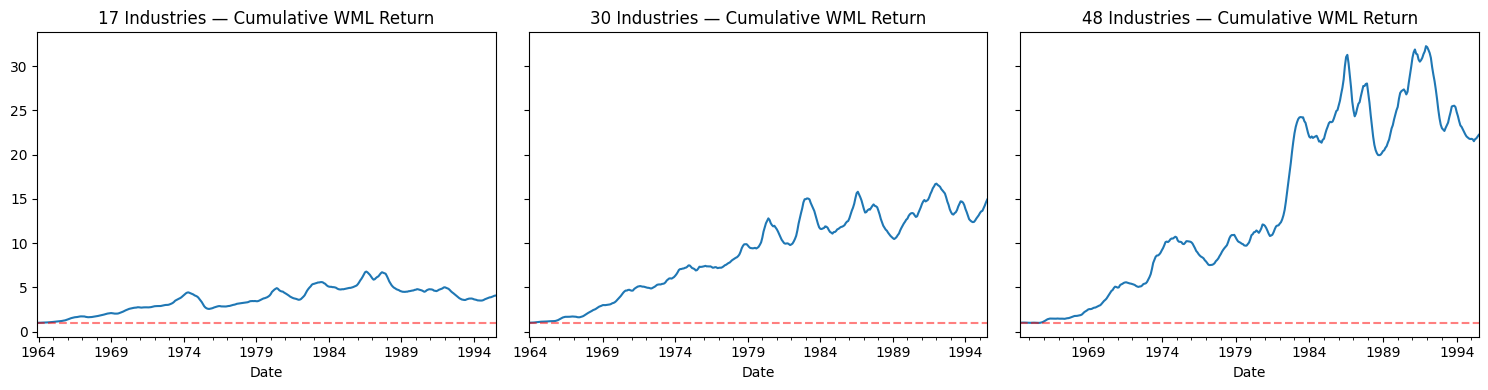

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (name, wml) in zip(axes, [('17', wml17), ('30', wml30), ('48', wml48)]):
    cumret = (1 + wml['wml'].dropna() / 100).cumprod()
    cumret.plot(ax=ax)
    ax.set_title(f'{name} Industries — Cumulative WML Return')
    ax.set_xlabel('Date')
    ax.axhline(y=1, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Replication: "Do Industries Explain Momentum?"
# Moskowitz & Grinblatt (1999), Journal of Finance
#
# This notebook replicates the core findings of the paper using
# Ken French's 17, 30, and 48 industry portfolio data.
# Sample period: July 1963 - July 1995